<a href="https://colab.research.google.com/github/viictorsauraa/AprendizajeporRefuerzo_SauraCarmonaCortesGrupo7/blob/main/Entornos_Complejos/SARSA_experiment_CLIFF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
if 'google.colab' in str(get_ipython()):
    if not os.path.exists('/content/AprendizajeporRefuerzo_SauraCarmonaCortesGrupo7'):
        !git clone https://github.com/viictorsauraa/AprendizajeporRefuerzo_SauraCarmonaCortesGrupo7.git
    %cd /content/AprendizajeporRefuerzo_SauraCarmonaCortesGrupo7/Entornos_Complejos

# **SARSA en CliffWalking-v1**

_Estudio del algoritmo de Diferencia Temporal (TD) On-Policy_

Este notebook implementa y analiza el algoritmo **SARSA** (State-Action-Reward-State-Action) sobre el entorno **CliffWalking-v1** de Gymnasium. A diferencia de los métodos de Monte Carlo, SARSA utiliza **bootstrapping**, permitiendo al agente aprender de sus estimaciones actuales sin esperar al final del episodio.

### **SARSA**
- **Aprendizaje On-Policy**: El agente aprende sobre la política que está ejecutando actualmente (incluyendo la exploración $\epsilon$-greedy).
- **Diferencia Temporal (TD)**: Actualiza los valores $Q$ basándose en la recompensa inmediata y la estimación del siguiente estado-acción:
  $$Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha [R_{t+1} + \gamma Q(S_{t+1}, A_{t+1}) - Q(S_t, A_t)]$$
- **Comportamiento en CliffWalking-v1**: Al ser on-policy, SARSA aprende bajo la política $\varepsilon$-greedy que realmente ejecuta. Esto significa que el agente tiene en cuenta el riesgo de caer al acantilado durante la exploración, lo que le lleva a preferir una **ruta segura** alejada del borde (17 pasos) frente a la ruta óptima más corta (13 pasos) que bordea el acantilado.

## **1. Preparación del Entorno**

La preparación consta de las siguientes partes:
- **Instalación de dependencias**: librería `gymnasium`.
- **Importación de librerías**: `numpy`, `matplotlib`, `tqdm`.
- **Creación del entorno CliffWalking-v1**: espacio de observación `Discrete(48)`, espacio de acciones `Discrete(4)` (N, E, S, W), `render_mode='ansi'` para visualización en texto. El grid es de 4×12 casillas; la fila inferior contiene el acantilado (estados 37–46) con penalización -100.
- **Importación de clases del repositorio**: `SARSAAgent`, funciones de visualización.

##### _________ **Código de la Instalación e Importación**
----

In [1]:
%%capture
#@title Instalamos gymnasium
!pip install gymnasium

In [ ]:
#@title Importamos librerias
import sys
sys.path.insert(0, 'src')

import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import gymnasium as gym

from agents import SARSAAgent
from plotting import plot, plot_lengths, show_greedy_episode, print_q_summary, plot_comparison, plot_lengths_comparison

In [20]:
# @title Semilla para reproducibilidad (sección 5.4 del PDF)
# Patrón recomendado: fijar la misma semilla en NumPy, Python y Gymnasium.
# Sin PyTorch porque este notebook es tabular (no usa redes neuronales).
SEED = 2024

# Fijar la semilla en NumPy
np.random.seed(SEED)
np.random.default_rng(SEED)

# Fijar la semilla en Python (evita variabilidad en hashing)
os.environ['PYTHONHASHSEED'] = str(SEED)

print(f"Semilla fija: SEED = {SEED}")

Semilla fija: SEED = 2024


In [21]:
#@title Importamos el entorno CliffWalking-v1
env = gym.make('CliffWalking-v1', render_mode='ansi')
env.reset(seed=SEED)   # Fija la semilla del entorno (patrón sección 5.4 del PDF)

nS = env.observation_space.n  # 48
nA = env.action_space.n       # 4
print(f"Estados: {nS}, Acciones: {nA}")
print(f"Recompensas: -1 por paso | -100 caída al acantilado | 0 al llegar")
print()
# # Estado inicial de ejemplo
# obs, info = env.reset(seed=SEED)
# print(f"Estado inicial (seed={SEED}): {obs}")
# taxi_row, taxi_col, pass_loc, dest_idx = env.unwrapped.decode(obs)
# locs = ['R', 'G', 'Y', 'B', 'en taxi']
# print(f"  Taxi: ({taxi_row},{taxi_col}), Pasajero: {locs[pass_loc]}, Destino: {locs[dest_idx]}")
# print(env.render())

Estados: 48, Acciones: 4
Recompensas: -1 por paso | -100 caída al acantilado | 0 al llegar



## **2. Diseño del Agente**

El diseño del agente sigue el esquema de Gymnasium (sección 5.2): `__init__`, `get_action`, `update`, `stats`.

### **Política Epsilon-Greedy**
- El agente utiliza una política **$\epsilon$-soft** para garantizar la exploración continua del espacio de estados.
- Con probabilidad $1-\varepsilon$, selecciona la acción con el mayor valor $Q$ (explotación).
- Con probabilidad $\varepsilon$, selecciona una acción al azar (exploración).

### **Algoritmo SARSA**
- Implementado en la clase `SARSAAgent`, este algoritmo actualiza la tabla $Q$ en cada paso del entorno.
- A diferencia de Q-Learning, SARSA es más conservador ya que considera la acción real que el agente tomará en el siguiente paso (la cual podría ser una acción exploratoria arriesgada).

In [5]:

UP, RIGHT, DOWN, LEFT = 0,1,2,3
ACTION_NAMES = {0: 'N↑', 1: 'E→', 2: 'S↓', 3: 'W←', 4: 'PU', 5: 'DO'}
# La política greedy se obtiene con agent.pi_star(seed=SEED, action_names=ACTION_NAMES)

## **3. Experimentación**

### **3.1 Representaciones Gráficas**

**Gráfica 1 — Recompensa media acumulada**: $f(t) = \frac{\sum_{i=1}^{t} R_i}{t}$. En CliffWalking-v1, los primeros episodios con $\varepsilon$ alto acumulan muchas caídas al acantilado (-100 cada una), lo que hunde el promedio durante las fases iniciales. Al ser acumulada, puede estabilizarse en valores muy negativos; en este run la media final ronda **-8025** aunque el episodio greedy sea de -17.

**Gráfica 2 — Longitud de los episodios**: Mide cuántos pasos tarda el agente en llegar al objetivo o caer al acantilado.
1. **Inicio**: Los episodios son muy cortos porque el agente aleatorio cae al acantilado rápidamente (-100 y reset).
2. **Aprendizaje**: La longitud se estabiliza conforme el agente evita el acantilado y aprende a rodear por la fila superior.
3. **Convergencia**: La política greedy es de 17 pasos (ruta segura por la fila superior), pero la longitud media final del entrenamiento queda alrededor de **19 pasos** en este run.

**Función `show_greedy_episode`**: Permite observar el comportamiento final del agente sin exploración, verificando si ha aprendido a navegar desde el estado inicial (36, esquina inferior izquierda) hasta el objetivo (47, esquina inferior derecha) evitando el acantilado.

### **3.2 SARSA en CliffWalking-v1**

Se entrenan **10 000 episodios** con $\varepsilon$ con decaimiento: $\varepsilon = \min(1.0,\ 1000/(t+1))$, igual que en Q-Learning y MC para poder comparar después resultados.

El decaimiento es necesario porque:
- Al inicio, $\varepsilon$ alto favorece una exploración amplia (el agente aprende a no caer al acantilado a base de penalizaciones de -100).
- Al final, $\varepsilon \to 0$ hace que la política de comportamiento se acerque a la greedy, produciendo episodios más cortos y estables.

La semilla (`SEED=2024`) garantiza reproducibilidad. Se fija tanto en NumPy como en el entorno.

In [22]:
# @title Aprendizaje on-policy
agent_S = SARSAAgent(env, epsilon=1, alpha=0.1, discount_factor=0.99, decay=True)
agent_S.train(num_episodes=10000)
list_stats_S, list_lengths_S = agent_S.stats()
Q_S = agent_S.q_values

 10%|█         | 1002/10000 [01:23<12:16, 12.21it/s]

success: -64704.6510, epsilon: 1.0000


 24%|██▍       | 2409/10000 [02:38<00:06, 1244.12it/s]

success: -40001.0910, epsilon: 0.5000


 34%|███▍      | 3381/10000 [02:38<00:02, 2210.53it/s]

...

success: -10026.4093, epsilon: 0.1250


 97%|█████████▋| 9718/10000 [02:40<00:00, 3578.07it/s]

success: -8914.9161, epsilon: 0.1111


100%|██████████| 10000/10000 [02:40<00:00, 62.30it/s] 

success: -8025.6447, epsilon: 0.1000


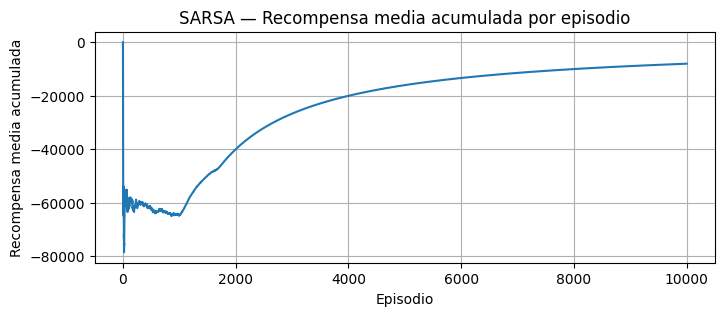

Recompensa media final: -8025.64


In [7]:
#@title Recompensa media acumulada por episodio (on-policy)
plot(list_stats_S, title='SARSA — Recompensa media acumulada por episodio', ylabel='Recompensa media acumulada')
print(f'Recompensa media final: {list_stats_S[-1]:.2f}')

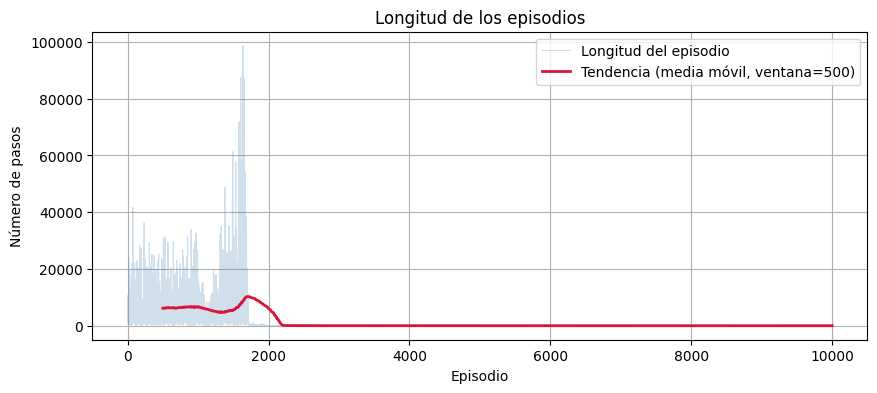

Longitud media final (últimos 1000 episodios): 19.33 pasos


In [8]:
#@title Longitud de episodios (on-policy)
plot_lengths(list_lengths_S)
print(f'Longitud media final (últimos 1000 episodios): {np.mean(list_lengths_S[-1000:]):.2f} pasos')

#### Resumen estadístico de la tabla Q aprendida. Con 48 estados y 4 acciones la tabla tiene 192 entradas.
Se muestran estadísticas globales y el desglose por estados para verificar que el agente ha aprendido valores coherentes con la dinámica del entorno.

Con **148 de 192 entradas visitadas** (77.1%), Max=0, Min=-289.398 y Mean=-49.794. El valor máximo de 0 corresponde al estado objetivo. Los valores muy negativos de Min y Mean reflejan el impacto de las caídas al acantilado (-100) durante el entrenamiento on-policy: SARSA actualiza Q con las acciones que realmente ejecuta (incluyendo exploración), por lo que los estados próximos al acantilado acumulan valores mucho más negativos que en Q-Learning (-112 de mínimo).

In [9]:
# @title Resumen tabla Q — on-policy
print_q_summary(env, Q_S, title="On-Policy — Tabla Q")

--- On-Policy — Tabla Q ---
  Entradas no nulas : 148/192 (77.1%)
  Max Q             : 0.000
  Min Q (no nulo)   : -289.398
  Q media (no nulo) : -49.794


Se muestra la política óptima greedy obtenida. `agent.pi_star(seed, action_names)` sigue `argmax Q[s]` desde el estado inicial fijo (semilla SEED, estado 36: esquina inferior izquierda) y devuelve la secuencia de acciones en formato legible (N↑ E→ S↓ W←). También se ejecuta `show_greedy_episode` para verificar visualmente el resultado en formato ANSI.

SARSA, al ser on-policy, aprende los valores Q bajo la política exploratoria $\varepsilon$-greedy. Esto hace que los estados cercanos al acantilado tengan valores penalizados por las caídas durante el entrenamiento, empujando la política greedy resultante a preferir la **ruta segura**: `N↑×3 → E→×11 → S↓×3` (17 pasos, recompensa -17), alejada del borde.

In [10]:
# @title Política final (on-policy)
pi, actions = agent_S.pi_star(seed=SEED, action_names=ACTION_NAMES)
print("Política óptima obtenida (on-policy)")
print(f"Acciones: {actions}")
print()
show_greedy_episode(env, Q_S, seed=SEED, title="SARSA — Episodio greedy")

Política óptima obtenida (on-policy)
Acciones: N↑ → N↑ → N↑ → E→ → E→ → E→ → E→ → E→ → E→ → E→ → E→ → E→ → E→ → E→ → S↓ → S↓ → S↓

SARSA — Episodio greedy  |  Recompensa: -17  |  Pasos: 17  |  Terminado

Estado inicial:
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
x  C  C  C  C  C  C  C  C  C  C  T


Estado final:
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  C  C  C  C  C  C  C  C  C  C  x




In [11]:
# state, info = env.reset(seed=SEED)
# # Extraer: taxi_row, taxi_col, pass_loc, dest_idx
# _, _, pass_loc, dest_idx = env.unwrapped.decode(state)

# plot_policy_taxi(env, agent_S.q_values, passenger_loc=pass_loc, destination_idx=dest_idx)

### **3.3 Modificación de parámetros de SARSA**

Los hiperparámetros en el algoritmo SARSA son fundamentales para equilibrar la explotación versus la exploración y cómo se gestionan las nuevas experiencias.

- La tasa de aprendizaje ($\alpha$) controla qué tan rápido el agente actualiza sus valores Q ante nueva información; un valor elevado puede acelerar la convergencia inicial pero generar inestabilidad, mientras que un valor bajo asegura una convergencia más suave y robusta.
- El parámetro épsilon ($\varepsilon$) determina el grado de exploración. En CliffWalking, la exploración tiene un coste especialmente alto (caídas al acantilado de -100), por lo que reducir $\varepsilon$ prematuramente puede hacer que el agente aprenda una política subóptima, mientras que mantenerlo alto retrasa la convergencia y acumula más penalizaciones.
- El factor de descuento ($\gamma$) dicta la importancia de las recompensas futuras frente a las inmediatas. En CliffWalking, un $\gamma$ cercano a 1.0 es esencial para que el agente valore alcanzar el objetivo (recompensa 0 en el estado terminal) pese al coste de -1 por paso. Reducir $\gamma$ hace que el agente pierda perspectiva del largo plazo y no pueda planificar la ruta correctamente.

In [12]:
# @title Aprendizaje on-policy
agent_S = SARSAAgent(env, epsilon=0.01, alpha=0.1, discount_factor=0.99, decay=False)
agent_S.train(num_episodes=10000)
list_stats_S_epsilon, list_lengths_S_epsilon = agent_S.stats()
Q_S = agent_S.q_values

 19%|█▉        | 1902/10000 [00:00<00:01, 4383.35it/s]

success: -26.7700, epsilon: 0.0100
success: -21.1900, epsilon: 0.0100


 39%|███▉      | 3884/10000 [00:00<00:01, 4829.24it/s]

success: -19.2863, epsilon: 0.0100


 48%|████▊     | 4846/10000 [00:01<00:01, 4745.95it/s]

...

success: -17.0886, epsilon: 0.0100


 87%|████████▋ | 8662/10000 [00:01<00:00, 4730.23it/s]

success: -16.8810, epsilon: 0.0100
success: -16.6926, epsilon: 0.0100


100%|██████████| 10000/10000 [00:02<00:00, 4558.62it/s]

success: -16.5619, epsilon: 0.0100


In [13]:
# @title Aprendizaje on-policy
agent_S = SARSAAgent(env, epsilon=0.2, alpha=0.5, discount_factor=0.99, decay=True)
agent_S.train(num_episodes=10000)
list_stats_S_alpha, list_lengths_S_alpha = agent_S.stats()
Q_S = agent_S.q_values

 10%|█         | 1001/10000 [01:19<13:23, 11.19it/s]

success: -63814.6530, epsilon: 1.0000


 21%|██▏       | 2133/10000 [01:27<00:07, 1002.89it/s]

success: -34029.8805, epsilon: 0.5000


 33%|███▎      | 3276/10000 [01:28<00:04, 1678.50it/s]

...

success: -8545.8446, epsilon: 0.1250


 93%|█████████▎| 9302/10000 [01:30<00:00, 2939.17it/s]

success: -7599.9862, epsilon: 0.1111


100%|██████████| 10000/10000 [01:30<00:00, 110.22it/s]

success: -6843.2892, epsilon: 0.1000


In [16]:
# @title Aprendizaje on-policy
agent_S = SARSAAgent(env, epsilon=0.2, alpha=0.1, discount_factor=0.25, decay=True)
agent_S.train(num_episodes=11000)
list_stats_S_discount, list_lengths_S_discount = agent_S.stats()
Q_S = agent_S.q_values

  0%|          | 0/11000 [00:00<?, ?it/s]

 10%|█         | 1104/11000 [01:33<07:36, 21.67it/s]

success: -65078.9236, epsilon: 0.9091


 20%|██        | 2203/11000 [01:51<03:12, 45.78it/s] 

success: -34261.4523, epsilon: 0.4545


...

success: -13082.7717, epsilon: 0.1136


 90%|█████████ | 9908/11000 [11:44<00:47, 23.15it/s] 

success: -12555.1994, epsilon: 0.1010


100%|██████████| 11000/11000 [13:29<00:00, 13.59it/s]

success: -12082.2914, epsilon: 0.0909


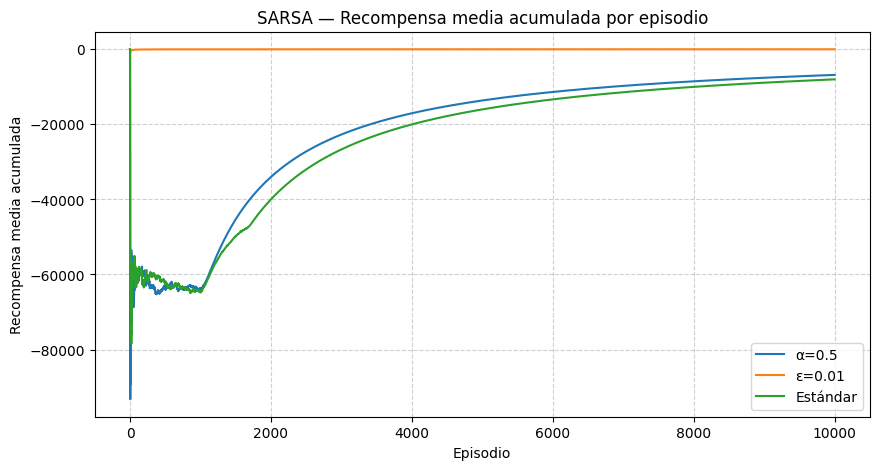

Recompensa media final de α=0.5: -6843.29
Recompensa media final de ε=0.01: -16.56
Recompensa media final de Estándar: -8025.64


In [17]:
#@title Recompensa media acumulada por episodio (on-policy)
lista_plots_recompensa = [list_stats_S_alpha, list_stats_S_epsilon, list_stats_S]
labels = ['α=0.5', 'ε=0.01', 'Estándar']
plot_comparison(lista_plots_recompensa, title='SARSA — Recompensa media acumulada por episodio', ylabel='Recompensa media acumulada', labels=labels)
for lista, label in zip(lista_plots_recompensa, labels):
    print(f'Recompensa media final de {label}: {lista[-1]:.2f}')

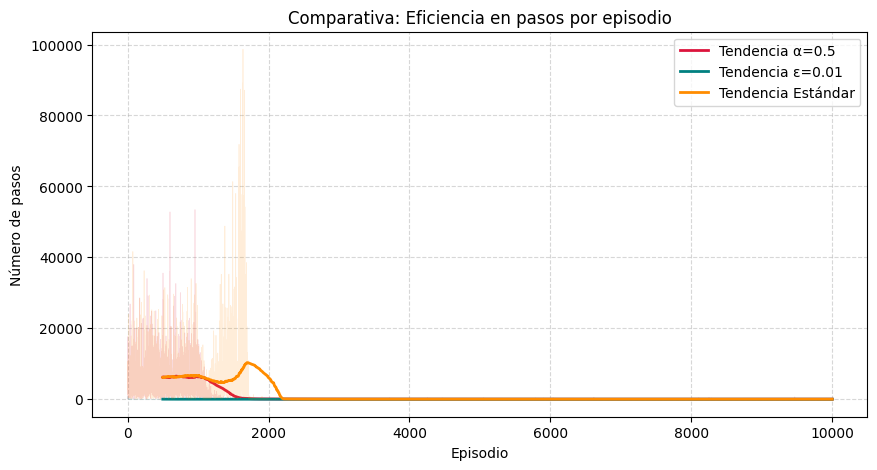

Longitud media final (últimos 1000 episodios) de α=0.5: 26.88 pasos
Longitud media final (últimos 1000 episodios) de ε=0.01: 15.19 pasos
Longitud media final (últimos 1000 episodios) de Estándar: 19.33 pasos


In [18]:
#@title Longitud de episodios (on-policy)
lista_plots_longitud = [list_lengths_S_alpha, list_lengths_S_epsilon, list_lengths_S]
plot_lengths_comparison(lista_plots_longitud, labels=labels)
for lista, label in zip(lista_plots_longitud, labels):
    print(f'Longitud media final (últimos 1000 episodios) de {label}: {np.mean(lista[-1000:]):.2f} pasos')

### **3.3.1 Análisis de los hiperparámetros**

### **3.3.1 Análisis de Resultados y Comparación de Configuraciones**

En esta sección se evalúa el impacto de los hiperparámetros en el aprendizaje de SARSA sobre CliffWalking-v1. Se han definido dos configuraciones específicas (más la original) para observar cómo cada parámetro afecta al entrenamiento:

1. **Configuración 1 ($\varepsilon=0.01$)** sin decaimiento: Minimiza la exploración desde el inicio. En CliffWalking, esto sugiere que el agente apenas cae al acantilado, lo que le permite acumular recompensas menos negativas rápidamente. La recompensa media final es de **-16.56**, muy próxima a la ruta greedy de -17, confirmando que aprende la política segura con pocas perturbaciones.
2. **Configuración 2 ($\alpha=0.5$)**: Aumenta la tasa de aprendizaje, lo que puede acelerar la absorción de experiencias de penalización severa (-100), pero también introduce más ruido en las actualizaciones. La recompensa media final es de **-6843.29**, mejor que la estándar pero muy lejos de $\varepsilon=0.01$; además, muestra episodios más largos (~27 pasos), lo que indica una política menos eficiente.
#### **Interpretación de las Gráficas**

**Recompensa Media Acumulada**:
- La configuración con $\varepsilon=0.01$ fijo obtiene la mejor recompensa media final (**-16.56**). Al explorar muy poco, el agente evita prácticamente todas las caídas al acantilado desde el inicio, aprendiendo rápidamente a seguir la ruta segura. En CliffWalking, a diferencia de entornos con estructuras de recompensa complejas, la exploración mínima es suficiente porque el objetivo es evitar una penalización obvia (-100).
- La configuración estándar obtiene una recompensa media de **-8025.64**, muy negativa debido a las caídas acumuladas en los primeros episodios con $\varepsilon \approx 1$. La media acumulada se ve dominada por las fases iniciales de exploración ciega, donde cada episodio puede acumular decenas de caídas al acantilado.
- La configuración con $\alpha=0.5$ obtiene **-6843.29**, mejor que la estándar, pero muy lejos de $\varepsilon=0.01$. Un $\alpha$ más alto amplifica el impacto de las penalizaciones de -100, causando oscilaciones más pronunciadas y dificultando la estabilización de los valores Q.

**Longitud de los Episodios**:
- Con $\varepsilon=0.01$, la longitud final es ~15 pasos, muy cercana a la ruta segura de 17.
- La configuración estándar se estabiliza alrededor de ~19 pasos.
- Con $\alpha=0.5$ la longitud final sube a ~27 pasos, señal de una política menos eficiente.

### **Guardar métricas (SARSA)**

Esta celda guarda las series para poder comparar con otros notebooks.


In [24]:
import os, numpy as np
os.makedirs('metrics', exist_ok=True)
np.savez('metrics/sarsa_cliff.npz', list_stats=list_stats_S, list_lengths=list_lengths_S)
print('Guardado: metrics/sarsa_cliff.npz')


Guardado: metrics/sarsa_cliff.npz
